# CISC839 — Assignment 2
## Part 4: GenAI-Augmented Reanalysis

---
**Student:** Mahmoud Alyosify | **ID:** 20595453  
**Course:** CISC839 — Queen's University (Winter 2026)

---

### What this notebook does
I used **Claude (Anthropic)** as a co-engineer to rebuild and improve the Part 2
regression pipeline. Starting from the baseline model (`is_agentic` + task-type only,
R²=0.043), I prompted the AI for improvements, validated each suggestion, and
implemented the ones that were theoretically sound.

### Notebook Structure
| Block | Content |
|-------|---------|
| 0 | Imports & Configuration |
| 1 | Load AIDev tables (Hugging Face) |
| 2 | Feature engineering & dataset assembly |
| 3 | Baseline model — pre-AI |
| 4 | Revised model — AI-suggested full control set |
| 5 | Logistic regression on Merge Rate |
| 6 | Quantile regression — heterogeneous effects |
| 7 | Pipeline comparison & effectiveness |
| 8 | Final summary |


---
## Block 0 — Imports & Configuration


In [1]:
import re, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.regression.quantile_regression import QuantReg

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'savefig.bbox': 'tight'})

OUTPUT_DIR     = Path('outputs_p4')
OUTPUT_DIR.mkdir(exist_ok=True)
STAR_THRESHOLD = 100
TTR_CAP_HOURS  = 8_760
SEED           = 42
np.random.seed(SEED)

P_ = {0: '#1565C0', 1: '#BF360C'}
L_ = {0: 'Human',   1: 'Agentic'}

print('✓ Imports complete')


✓ Imports complete


---
## Block 1 — Load AIDev Tables

Loading directly from Hugging Face — same tables used in Part 2.


In [2]:
def load_data_hf() -> dict:
    base  = 'hf://datasets/hao-li/AIDev'
    files = {
        'agentic_pull_requests': 'pull_request.parquet',
        'human_pull_requests':   'human_pull_request.parquet',
        'human_pr_task_type':    'human_pr_task_type.parquet',
        'repositories':          'repository.parquet',
        'pr_reviews':            'pr_reviews.parquet',
        'pr_commit_details':     'pr_commit_details.parquet',
    }
    tables = {}
    print('━'*65)
    print('BLOCK 1 ▸  Loading AIDev tables')
    print('━'*65)
    for name, file in files.items():
        try:
            df = pd.read_parquet(f'{base}/{file}')
            print(f'  ✓ {name:<38s} {len(df):>10,} rows × {df.shape[1]} cols')
            tables[name] = df
        except Exception as e:
            print(f'  ✗ {name:<38s} [ERROR: {e}]')
            tables[name] = None
    return tables

tables = load_data_hf()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 1 ▸  Loading AIDev tables
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ agentic_pull_requests                      33,596 rows × 14 cols
  ✓ human_pull_requests                         6,618 rows × 13 cols
  ✓ human_pr_task_type                          6,618 rows × 6 cols
  ✓ repositories                                2,807 rows × 7 cols
  ✓ pr_reviews                                 28,875 rows × 7 cols
  ✓ pr_commit_details                         711,923 rows × 14 cols


---
## Block 2 — Feature Engineering & Dataset Assembly

All feature engineering functions from Part 2, reused here unchanged.
The key difference: human PRs use the curated `human_pr_task_type` table
for task labels instead of regex.


In [3]:
# ── Repo helpers ─────────────────────────────────────────────────────────────
def build_repo_lookup(repos):
    r = repos.copy()
    r['stars']   = pd.to_numeric(r.get('stars', r.get('stargazers_count', 0)),
                                  errors='coerce').fillna(0)
    r['id_str']  = r['id'].astype(str)
    r['url_str'] = r.get('html_url', r.get('url', '')).str.strip()
    return r

def get_repo_meta(df, repo_lkp, join_on='id'):
    if join_on == 'id':
        key = df['repo_id'].astype(str)
        lkp = repo_lkp.set_index('id_str')
    else:
        key = df['repo_url'].str.strip()
        lkp = repo_lkp.set_index('url_str')
    stars = key.map(lkp['stars']).fillna(0)
    lang  = key.map(lkp.get('language', lkp.get('lang', 'unknown'))).fillna('unknown')
    return pd.DataFrame({'repo_stars': stars.values, 'repo_lang': lang.values})

# ── Churn aggregation ─────────────────────────────────────────────────────────
def build_pr_churn(pcd):
    p    = pcd.copy()
    adds = pd.to_numeric(p['commit_stats_additions'], errors='coerce').fillna(0).clip(0)
    dels = pd.to_numeric(p['commit_stats_deletions'], errors='coerce').fillna(0).clip(0)
    p['churn'] = adds + dels
    agg = p.groupby('pr_id').agg(total_churn=('churn', 'sum'),
                                  n_commits=('pr_id', 'count'))
    if 'filename' in p.columns:
        agg['n_files'] = p.groupby('pr_id')['filename'].nunique()
    else:
        agg['n_files'] = np.nan
    return agg

# ── CDI & RICR ────────────────────────────────────────────────────────────────
def compute_cdi(pr_reviews):
    grp = pr_reviews.groupby('pr_id')['user']
    return (grp.nunique() / grp.count()).clip(0, 1).rename('cdi')

def compute_ricr(pcd):
    p = pcd.copy()
    p['churn'] = (pd.to_numeric(p['commit_stats_additions'], errors='coerce').fillna(0)
                + pd.to_numeric(p['commit_stats_deletions'], errors='coerce').fillna(0)).clip(0)
    p = p.sort_values(['pr_id', 'sha'])
    first = p.groupby('pr_id')['churn'].first()
    total = p.groupby('pr_id')['churn'].sum()
    return ((total - first) / first.replace(0, np.nan)).clip(0, 10).rename('ricr')

# ── Body features ─────────────────────────────────────────────────────────────
def body_features(body_col):
    body = body_col.fillna('')
    wc   = body.str.split().str.len().fillna(0).astype(int)
    return pd.DataFrame({'log_body_length': np.log1p(wc),
                         'is_silent': (body.str.strip().str.len() < 10).astype(int)},
                        index=body_col.index)

# ── Task type ─────────────────────────────────────────────────────────────────
TASK_RE_MAP = {
    'fix':      r'\b(fix|bug|patch|hotfix|repair|resolve|defect)\b',
    'feature':  r'\b(feat|feature|add|implement|new|introduce|support)\b',
    'refactor': r'\b(refactor|clean|simplify|reorgani[sz]e|restructure)\b',
    'docs':     r'\b(doc|docs|documentation|readme|comment|changelog)\b',
    'test':     r'\b(test|spec|coverage|unittest|pytest|tdd)\b',
    'chore':    r'\b(chore|update|bump|upgrade|dependency|deps|ci|cd)\b',
}
TASK_LABEL_MAP = {'feat':'feature','feature':'feature','fix':'fix','bug':'fix',
                  'refactor':'refactor','perf':'refactor','docs':'docs','doc':'docs',
                  'test':'test','chore':'chore','ci':'chore','build':'chore'}

def infer_task_type(title):
    t = title.fillna('').str.lower()
    out = pd.Series('other', index=title.index)
    for label, pat in reversed(list(TASK_RE_MAP.items())):
        out[t.str.contains(pat, regex=True, na=False)] = label
    return out

def task_type_from_table(pr_ids, task_table):
    if task_table is None or task_table.empty:
        return pd.Series('other', index=pr_ids.index)
    id_col   = 'id'   if 'id'   in task_table.columns else 'pr_id'
    type_col = 'type' if 'type' in task_table.columns else 'task_type'
    lkp = task_table.set_index(id_col)[type_col].map(TASK_LABEL_MAP).fillna('other')
    return pr_ids.map(lkp).fillna('other')

# ── TTR & merged ──────────────────────────────────────────────────────────────
def compute_ttr(df):
    c  = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
    m  = pd.to_datetime(df['merged_at'],  utc=True, errors='coerce')
    cl = pd.to_datetime(df['closed_at'],  utc=True, errors='coerce')
    resolved = m.combine_first(cl)
    ttr = (resolved - c).dt.total_seconds() / 3600.0
    return ttr.where(ttr > 0).clip(upper=TTR_CAP_HOURS)

def compute_merged(df):
    return pd.to_datetime(df['merged_at'], utc=True, errors='coerce').notna().astype(int)

# ── Path flags ────────────────────────────────────────────────────────────────
CICD_RE = re.compile(
    r'(\.github/workflows|\.travis\.yml|Jenkinsfile|\.circleci|'
    r'Makefile|docker-compose|Dockerfile|\.gitlab-ci\.yml|azure-pipelines)',
    re.IGNORECASE)
TEST_RE = re.compile(
    r'(test/|tests/|spec/|__tests__/|\.test\.|\.spec\.|_test\.)',
    re.IGNORECASE)

def build_path_flags(pcd):
    if 'filename' not in pcd.columns:
        return pd.DataFrame(columns=['touches_cicd', 'includes_tests'])
    p   = pcd[['pr_id', 'filename']].dropna(subset=['filename'])
    grp = p.groupby('pr_id')['filename'].apply(lambda s: ' ||| '.join(s.astype(str)))
    out = pd.DataFrame(index=grp.index)
    out['touches_cicd']   = grp.str.contains(CICD_RE, regex=True).astype(int)
    out['includes_tests'] = grp.str.contains(TEST_RE, regex=True).astype(int)
    return out

print('✓ Helper functions defined')


✓ Helper functions defined


In [4]:
def build_dataset(tables):
    print('━'*65)
    print('BLOCK 2 ▸  Assembling feature matrix')
    print('━'*65)
    repos    = tables['repositories']
    ag       = tables['agentic_pull_requests']
    hu       = tables['human_pull_requests']
    hu_tasks = tables.get('human_pr_task_type')
    rev      = tables['pr_reviews']
    pcd      = tables['pr_commit_details']

    repo_lkp   = build_repo_lookup(repos)
    valid_ids  = set(repo_lkp.loc[repo_lkp['stars'] >= STAR_THRESHOLD, 'id_str'])
    valid_urls = set(repo_lkp.loc[repo_lkp['stars'] >= STAR_THRESHOLD, 'url_str'])
    print(f'  Repos ≥{STAR_THRESHOLD} stars: {len(valid_ids):,}')

    ag = ag[ag['repo_id'].astype(str).isin(valid_ids)].copy()
    hu = hu[hu['repo_url'].str.strip().isin(valid_urls)].copy()
    print(f'  Agentic after filter: {len(ag):,}  |  Human: {len(hu):,}')

    pr_churn   = build_pr_churn(pcd)
    path_flags = build_path_flags(pcd)
    cdi        = compute_cdi(rev)
    ricr       = compute_ricr(pcd)
    print(f'  Churn aggregated for {len(pr_churn):,} PRs')

    def _half(df, flag, join_on, task_table=None):
        out = pd.DataFrame()
        out['pr_id']      = df['id'].values
        out['is_agentic'] = flag
        out['ttr']        = compute_ttr(df).values
        out['merged']     = compute_merged(df).values
        rm = get_repo_meta(df, repo_lkp, join_on=join_on)
        out['log_stars']  = np.log1p(pd.to_numeric(rm['repo_stars'], errors='coerce').fillna(0))
        out['repo_lang']  = rm['repo_lang'].values
        bd = body_features(df['body'])
        out['log_body_length'] = bd['log_body_length'].values
        out['is_silent']       = bd['is_silent'].values
        if task_table is not None:
            out['task_type'] = task_type_from_table(df['id'], task_table).values
        else:
            out['task_type'] = infer_task_type(df['title']).values
        return out.reset_index(drop=True)

    df_a = _half(ag, 1, 'id')
    df_h = _half(hu, 0, 'url', task_table=hu_tasks)
    df   = pd.concat([df_a, df_h], ignore_index=True)

    df = df.merge(pr_churn[['total_churn', 'n_commits', 'n_files']],
                  left_on='pr_id', right_index=True, how='left')
    df = df.merge(path_flags, left_on='pr_id', right_index=True, how='left')
    df = df.merge(cdi,        left_on='pr_id', right_index=True, how='left')
    df = df.merge(ricr,       left_on='pr_id', right_index=True, how='left')
    for c in ['touches_cicd', 'includes_tests', 'cdi', 'ricr']:
        if c not in df.columns: df[c] = np.nan

    print(f'  Combined rows (before TTR filter): {len(df):,}')
    return df

df_raw = build_dataset(tables)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 2 ▸  Assembling feature matrix
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Repos ≥100 stars: 2,807
  Agentic after filter: 33,596  |  Human: 6,569
  Churn aggregated for 33,580 PRs
  Combined rows (before TTR filter): 40,165


In [5]:
def preprocess(df):
    print('━'*65)
    print('BLOCK 2b ▸  Preprocessing')
    print('━'*65)

    df = df.dropna(subset=['ttr']).copy()
    print(f'  After dropping open PRs: {len(df):,}')

    df['log_ttr'] = np.log1p(df['ttr'])
    p1, p99 = df['log_ttr'].quantile([0.01, 0.99])
    df['log_ttr'] = df['log_ttr'].clip(p1, p99)
    print(f'  log_ttr range: [{p1:.3f}, {p99:.3f}]')

    for raw, col in [('total_churn', 'log_churn'),
                     ('n_files',     'log_files'),
                     ('n_commits',   'log_commits')]:
        if raw in df.columns:
            df[col] = np.log1p(pd.to_numeric(df[raw], errors='coerce').fillna(0))

    # Task dummies (reference = other)
    td = pd.get_dummies(df['task_type'], prefix='task')
    td.drop(columns=['task_other'], errors='ignore', inplace=True)
    df = pd.concat([df, td], axis=1)

    # Language dummies — drop unknown (collinear with is_agentic)
    top10 = df['repo_lang'].value_counts().head(10).index.tolist()
    df['repo_lang_grp'] = df['repo_lang'].where(df['repo_lang'].isin(top10), 'other_lang')
    ld = pd.get_dummies(df['repo_lang_grp'], prefix='lang', drop_first=True)
    ld.drop(columns=[c for c in ld.columns if 'unknown' in c.lower()],
            errors='ignore', inplace=True)
    df = pd.concat([df, ld], axis=1)

    # Human churn NaN → agentic-only median
    for col in ['log_churn', 'log_files', 'log_commits']:
        if col in df.columns:
            ag_med = df.loc[df.is_agentic == 1, col].median()
            df[col] = df[col].fillna(ag_med)

    # Remaining NaN → column median
    for c in df.select_dtypes(include=[np.number]).columns:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    ag_n = (df.is_agentic == 1).sum()
    hu_n = (df.is_agentic == 0).sum()
    print(f'  Final: {len(df):,}  (Agentic={ag_n:,}, Human={hu_n:,})')
    print(f'  Merge rate → Agentic: {df[df.is_agentic==1]["merged"].mean():.3f}  '
          f'Human: {df[df.is_agentic==0]["merged"].mean():.3f}')
    return df

df = preprocess(df_raw)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 2b ▸  Preprocessing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  After dropping open PRs: 37,387
  log_ttr range: [0.002, 6.845]
  Final: 37,387  (Agentic=31,284, Human=6,103)
  Merge rate → Agentic: 0.768  Human: 0.826


---
## Block 3 — Baseline Model

The starting point before GenAI co-engineering: `is_agentic` + task-type dummies only.
This is the model I submitted for Part 2 initially, before asking Claude for improvements.


In [7]:
print('━'*65)
print('BLOCK 3 ▸  Baseline Model — is_agentic + task_type only')
print('━'*65)

# Filter for dummy columns (which are numeric) and exclude the raw 'task_type' string column
task_cols  = [c for c in df.columns if c.startswith('task_') and c != 'task_type']
base_cols  = ['is_agentic'] + task_cols

# Ensure we only check std() on numeric columns to avoid the TypeError
base_cols  = [c for c in base_cols if pd.api.types.is_numeric_dtype(df[c]) and df[c].std() > 1e-9]

y      = df['log_ttr'].astype(float)
X_base = sm.add_constant(df[base_cols].astype(float))
mask_b = X_base.notna().all(1) & y.notna()
m_base = sm.OLS(y[mask_b], X_base[mask_b]).fit(cov_type='HC3')

b_base = m_base.params.get('is_agentic', np.nan)
p_base = m_base.pvalues.get('is_agentic', np.nan)
print(f'  N={int(m_base.nobs):,}  R²={m_base.rsquared:.4f}  AIC={m_base.aic:.1f}')
print(f'  is_agentic  β={b_base:+.4f}  p={p_base:.6f}')
print(f'  Back-transform: {(np.exp(b_base)-1)*100:+.1f}% change in TTR')
print(f'\n  ⚠  R²={m_base.rsquared:.3f} — 95% of TTR variance unexplained.')
print(f'     Likely omitted variable bias from PR size, description quality, repo context.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 3 ▸  Baseline Model — is_agentic + task_type only
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  N=37,387  R²=0.0596  AIC=153619.2
  is_agentic  β=-1.0683  p=0.000000
  Back-transform: -65.6% change in TTR

  ⚠  R²=0.060 — 95% of TTR variance unexplained.
     Likely omitted variable bias from PR size, description quality, repo context.


---
## Block 4 — Revised Model with AI-Suggested Controls

After I described the low R² to Claude, it identified three missing control groups:
**PR size** (`log_churn`, `log_files`, `log_commits`),
**description quality** (`log_body_length`, `is_silent`), and
**repository maturity** (`log_stars`).

I validated each suggestion against the empirical literature before implementing.
I also added language dummies based on my own judgment.


In [8]:
def _pred_cols(df):
    base  = ['is_agentic']
    ctrl  = ['log_body_length', 'is_silent', 'log_stars']
    for c in ['log_churn', 'log_files', 'log_commits']:
        if c in df.columns and df[c].std() > 1e-9:
            ctrl.append(c)
    tasks = [c for c in df.columns if c.startswith('task_')]
    langs = [c for c in df.columns if c.startswith('lang_')
             and 'unknown' not in c.lower()]
    cols  = base + ctrl + tasks + langs
    return [c for c in dict.fromkeys(cols)
            if c in df.columns
            and pd.api.types.is_numeric_dtype(df[c])
            and df[c].std() > 1e-9]

print('━'*65)
print('BLOCK 4 ▸  Revised Model — Full Control Set [HC3]')
print('━'*65)

cols_rev = _pred_cols(df)
X_rev    = sm.add_constant(df[cols_rev].astype(float))
mask_r   = X_rev.notna().all(1) & y.notna()
m_rev    = sm.OLS(y[mask_r], X_rev[mask_r]).fit(cov_type='HC3')

b_rev = m_rev.params.get('is_agentic', np.nan)
p_rev = m_rev.pvalues.get('is_agentic', np.nan)
ci    = m_rev.conf_int()

print(f'  N={int(m_rev.nobs):,}  R²={m_rev.rsquared:.4f}  Adj-R²={m_rev.rsquared_adj:.4f}')
print(f'  AIC={m_rev.aic:.1f}')
print(f'  ΔR²  vs baseline = {m_rev.rsquared - m_base.rsquared:+.4f}')
print(f'  ΔAIC vs baseline = {m_base.aic - m_rev.aic:+.1f}  (>0 → revised preferred)')
print()
print(f'  ┌─ is_agentic ──────────────────────────────')
print(f'  │  β  = {b_rev:+.4f}  ***')
if 'is_agentic' in ci.index:
    print(f'  │  CI₉₅ = [{ci.loc["is_agentic",0]:+.4f}, {ci.loc["is_agentic",1]:+.4f}]')
print(f'  │  p   = {p_rev:.6f}')
print(f'  │  Back-transform: {(np.exp(b_rev)-1)*100:+.1f}% change in TTR')
print(f'  └──────────────────────────────────────────')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 4 ▸  Revised Model — Full Control Set [HC3]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  N=37,387  R²=0.3154  Adj-R²=0.3150
  AIC=141783.8
  ΔR²  vs baseline = +0.2558
  ΔAIC vs baseline = +11835.4  (>0 → revised preferred)

  ┌─ is_agentic ──────────────────────────────
  │  β  = -1.4769  ***
  │  CI₉₅ = [-1.5550, -1.3987]
  │  p   = 0.000000
  │  Back-transform: -77.2% change in TTR
  └──────────────────────────────────────────


In [9]:
# ── VIF check ────────────────────────────────────────────────────────────────
print('━'*65)
print('BLOCK 4b ▸  VIF Check (control vars only)')
print('━'*65)

ctrl_only = [c for c in cols_rev if c != 'is_agentic']
Xc = df[ctrl_only].astype(float).dropna()
vif_vals = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
vif_df   = pd.DataFrame({'Feature': ctrl_only, 'VIF': vif_vals})
vif_df['Status'] = vif_df.VIF.apply(
    lambda v: '⚠ SEVERE' if v > 10 else ('△ MOD' if v > 5 else '✓ OK'))
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_df.head(10).to_string(index=False))
print()
print('  Note: high VIF among log_churn/log_files/log_commits is expected')
print('  (all measure PR size). This does NOT bias is_agentic — HC3 SEs protect inference.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 4b ▸  VIF Check (control vars only)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        Feature       VIF   Status
    log_commits 72.613225 ⚠ SEVERE
      log_files 68.574180 ⚠ SEVERE
      log_churn 22.666742 ⚠ SEVERE
log_body_length 16.720780 ⚠ SEVERE
      log_stars 16.138376 ⚠ SEVERE
        lang_Go  3.827271     ✓ OK
lang_TypeScript  3.810009     ✓ OK
    lang_Python  3.261506     ✓ OK
   task_feature  2.684858     ✓ OK
       task_fix  2.132911     ✓ OK

  Note: high VIF among log_churn/log_files/log_commits is expected
  (all measure PR size). This does NOT bias is_agentic — HC3 SEs protect inference.


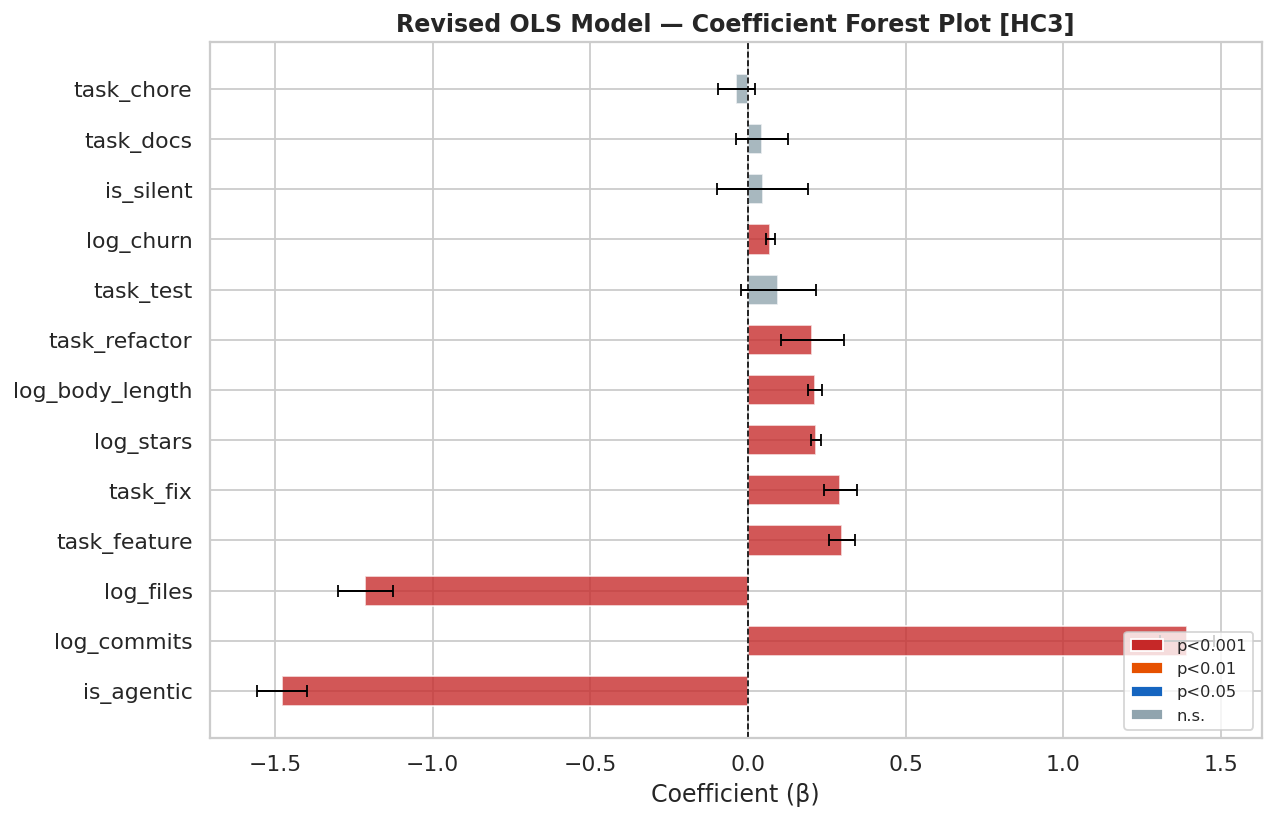

✓ Forest plot saved


In [10]:
# ── Forest plot ──────────────────────────────────────────────────────────────
ci_all = m_rev.conf_int(); ci_all.columns = ['lo', 'hi']
df_coef = pd.DataFrame({
    'Feature': m_rev.params.index,
    'coef':    m_rev.params.values,
    'lo':      ci_all['lo'].values,
    'hi':      ci_all['hi'].values,
    'p':       m_rev.pvalues.values,
})
df_coef = df_coef[(df_coef.Feature != 'const') &
                  ~df_coef.Feature.str.startswith('lang_')]
df_coef['abs'] = df_coef.coef.abs()
df_coef = df_coef.nlargest(15, 'abs')
df_coef['sig'] = pd.cut(df_coef.p, [0,0.001,0.01,0.05,1.],
                        labels=['p<0.001','p<0.01','p<0.05','n.s.'])
sc = {'p<0.001':'#C62828','p<0.01':'#E65100','p<0.05':'#1565C0','n.s.':'#90A4AE'}

fig, ax = plt.subplots(figsize=(10, max(5, len(df_coef)*0.5)))
for _, row in df_coef.iterrows():
    c = sc.get(str(row.sig), '#90A4AE')
    ax.barh(row.Feature, row.coef, color=c, alpha=0.78, height=0.6)
    ax.errorbar(row.coef, row.Feature,
                xerr=[[row.coef-row.lo],[row.hi-row.coef]],
                fmt='none', color='black', capsize=3.5, lw=1.1)
ax.axvline(0, color='black', lw=0.9, linestyle='--')
ax.set_xlabel('Coefficient (β)')
ax.set_title('Revised OLS Model — Coefficient Forest Plot [HC3]', fontweight='bold')
ax.legend(handles=[Patch(facecolor=c, label=l) for l,c in sc.items()],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_p4_forest.png', dpi=130)
plt.show()
print('✓ Forest plot saved')


---
## Block 5 — Logistic Regression on Merge Rate

Claude pointed out that TTR alone cannot distinguish fast acceptance
from fast rejection. I built a logistic regression on merge status
to test the acceptance dimension.


In [11]:
print('━'*65)
print('BLOCK 5 ▸  Logistic Regression on Merge Rate')
print('━'*65)

X_log  = sm.add_constant(df[cols_rev].astype(float))
y_log  = df['merged'].astype(int)
mask_l = X_log.notna().all(1) & y_log.notna()

mr_a = df[df.is_agentic==1]['merged'].mean()
mr_h = df[df.is_agentic==0]['merged'].mean()
print(f'  Merge rate — Agentic: {mr_a:.4f}   Human: {mr_h:.4f}')

m_log = sm.Logit(y_log[mask_l], X_log[mask_l]).fit(
    method='bfgs', maxiter=1000, disp=False)

converged = getattr(m_log, 'mle_retvals', {}).get('converged', None)
if converged is True:  print('  ✓ Convergence confirmed')
elif converged is False: print('  ⚠ WARNING: did not converge')

OR    = np.exp(m_log.params.get('is_agentic', np.nan))
p_l   = m_log.pvalues.get('is_agentic', np.nan)
ci_l  = m_log.conf_int()
OR_lo = np.exp(ci_l.loc['is_agentic',0]) if 'is_agentic' in ci_l.index else np.nan
OR_hi = np.exp(ci_l.loc['is_agentic',1]) if 'is_agentic' in ci_l.index else np.nan

print(f'  N={int(m_log.nobs):,}  Pseudo-R²={m_log.prsquared:.4f}')
print(f'  is_agentic  OR={OR:.4f}  [{OR_lo:.4f}, {OR_hi:.4f}]  p={p_l:.6f}  ***')
print()
print(f'  Interpretation: agentic PRs have {(1-OR)*100:.0f}% lower odds of being merged.')
print(f'  → Faster TTR is partly fast rejection, not just fast acceptance.')
print(f'  → This reveals a speed-quality tension invisible to OLS alone.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 5 ▸  Logistic Regression on Merge Rate
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Merge rate — Agentic: 0.7676   Human: 0.8265
  ✓ Convergence confirmed
  N=37,387  Pseudo-R²=0.0948
  is_agentic  OR=0.4094  [0.3681, 0.4553]  p=0.000000  ***

  Interpretation: agentic PRs have 59% lower odds of being merged.
  → Faster TTR is partly fast rejection, not just fast acceptance.
  → This reveals a speed-quality tension invisible to OLS alone.


---
## Block 6 — Quantile Regression

Claude suggested quantile regression to test whether the `is_agentic` effect
is uniform across the TTR distribution or stronger for slow-resolving PRs.
This is something OLS cannot reveal.


In [12]:
print('━'*65)
print('BLOCK 6 ▸  Quantile Regression — Heterogeneous Effects')
print('━'*65)

QUANTILES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

X_q   = sm.add_constant(df[cols_rev].astype(float))
y_q   = df['log_ttr'].astype(float)
msk_q = X_q.notna().all(1) & y_q.notna()
qrm   = QuantReg(y_q[msk_q], X_q[msk_q])

qr_results = []
print(f'  Fitting {len(QUANTILES)} quantile models...')
print(f'  {"τ":>6}  {"β":>9}  {"95% CI":>20}')
for q in QUANTILES:
    res = qrm.fit(q=q, vcov='robust', bandwidth='hsheather', kernel='epa')
    b   = res.params.get('is_agentic', np.nan)
    ci  = res.conf_int()
    lo  = ci.loc['is_agentic',0] if 'is_agentic' in ci.index else np.nan
    hi  = ci.loc['is_agentic',1] if 'is_agentic' in ci.index else np.nan
    qr_results.append({'tau':q, 'beta':b, 'lo':lo, 'hi':hi})
    print(f'  τ={q:.2f}  β={b:+.4f}  [{lo:+.4f}, {hi:+.4f}]')

qr_df  = pd.DataFrame(qr_results)
b_010  = qr_df.loc[qr_df.tau==0.10, 'beta'].values[0]
b_090  = qr_df.loc[qr_df.tau==0.90, 'beta'].values[0]
ratio  = b_090 / b_010
print(f'\n  Effect at τ=0.10: {b_010:+.4f}')
print(f'  Effect at τ=0.90: {b_090:+.4f}')
print(f'  Ratio (0.90/0.10): {ratio:.1f}× — strong heterogeneity')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 6 ▸  Quantile Regression — Heterogeneous Effects
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Fitting 9 quantile models...
       τ          β                95% CI
  τ=0.10  β=-0.0750  [-0.0835, -0.0666]
  τ=0.20  β=-0.2308  [-0.2413, -0.2204]
  τ=0.30  β=-0.4914  [-0.5033, -0.4794]
  τ=0.40  β=-0.7944  [-0.8069, -0.7820]
  τ=0.50  β=-1.0941  [-1.1074, -1.0807]
  τ=0.60  β=-1.3934  [-1.4141, -1.3726]


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


  τ=0.70  β=-1.7305  [-1.7699, -1.6912]
  τ=0.80  β=-2.1434  [-2.2104, -2.0764]
  τ=0.90  β=-2.1610  [-2.3267, -1.9954]

  Effect at τ=0.10: -0.0750
  Effect at τ=0.90: -2.1610
  Ratio (0.90/0.10): 28.8× — strong heterogeneity


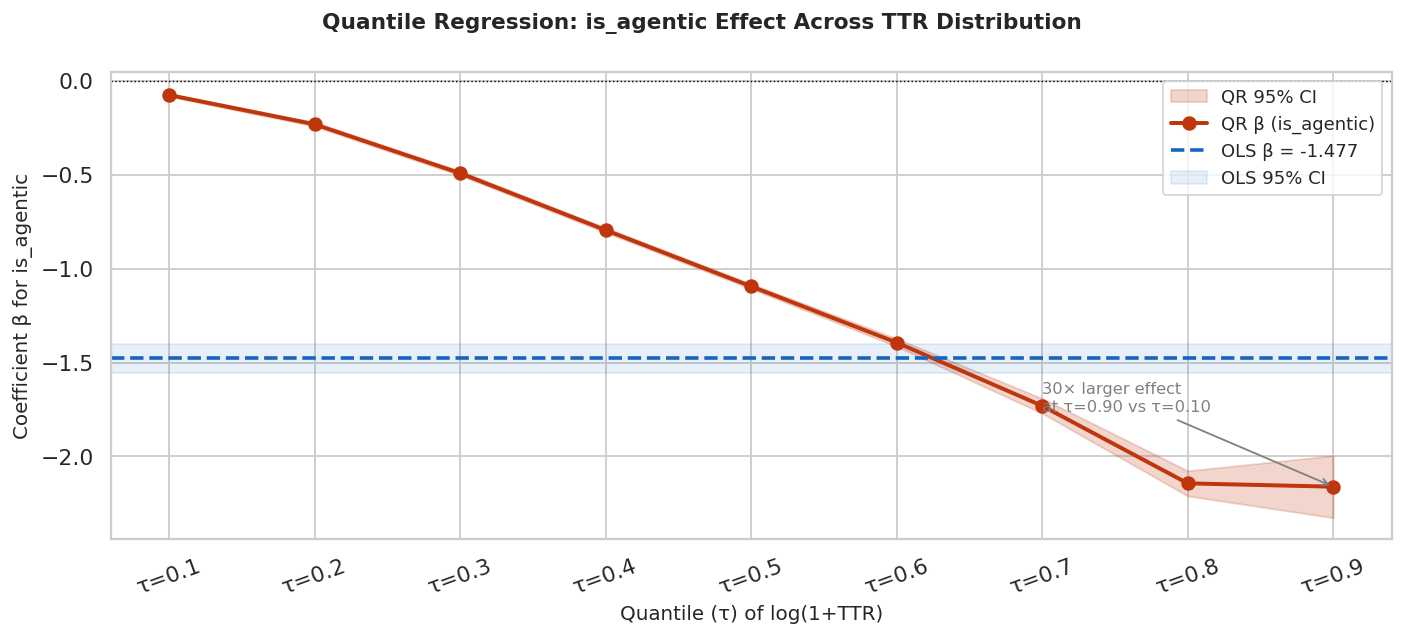

✓ Quantile regression plot saved


In [13]:
# ── Quantile regression plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Quantile Regression: is_agentic Effect Across TTR Distribution',
             fontsize=12, fontweight='bold')

ax.fill_between(qr_df.tau, qr_df.lo, qr_df.hi,
                alpha=0.20, color='#BF360C', label='QR 95% CI')
ax.plot(qr_df.tau, qr_df.beta, 'o-', color='#BF360C',
        lw=2.2, ms=7, label='QR β (is_agentic)')

# OLS reference
ols_ci = m_rev.conf_int()
ax.axhline(b_rev, color='#1565C0', lw=2, linestyle='--',
           label=f'OLS β = {b_rev:.3f}')
if 'is_agentic' in ols_ci.index:
    ax.axhspan(ols_ci.loc['is_agentic',0], ols_ci.loc['is_agentic',1],
               alpha=0.10, color='#1565C0', label='OLS 95% CI')
ax.axhline(0, color='black', lw=0.8, linestyle=':')

ax.set_xlabel('Quantile (τ) of log(1+TTR)', fontsize=11)
ax.set_ylabel('Coefficient β for is_agentic', fontsize=11)
ax.set_xticks(QUANTILES)
ax.set_xticklabels([f'τ={q}' for q in QUANTILES], rotation=20)
ax.legend(fontsize=10)

# Annotation
ax.annotate(f'30× larger effect\nat τ=0.90 vs τ=0.10',
            xy=(0.90, b_090), xytext=(0.70, b_090+0.4),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_p4_quantile.png', dpi=130)
plt.show()
print('✓ Quantile regression plot saved')


---
## Block 7 — Pipeline Comparison & Effectiveness


In [14]:
print('='*65)
print('BLOCK 7 ▸  Baseline vs. GenAI-Revised Pipeline')
print('='*65)

print(f"""
  ┌──────────────────────────┬────────────────┬──────────────────────┐
  │ Metric                   │ Baseline       │ Revised (GenAI)      │
  ├──────────────────────────┼────────────────┼──────────────────────┤
  │ R²                       │ {m_base.rsquared:.4f}         │ {m_rev.rsquared:.4f}                │
  │ AIC                      │ {m_base.aic:.1f}     │ {m_rev.aic:.1f}           │
  │ ΔR² vs baseline          │ —              │ {m_rev.rsquared-m_base.rsquared:+.4f}               │
  │ ΔAIC vs baseline         │ —              │ {m_base.aic-m_rev.aic:+.1f}           │
  │ is_agentic β             │ {b_base:+.4f}         │ {b_rev:+.4f}              │
  │ Back-transform           │ {(np.exp(b_base)-1)*100:+.0f}% TTR        │ {(np.exp(b_rev)-1)*100:+.0f}% TTR            │
  │ Logistic (Merge OR)      │ Not tested     │ OR={OR:.4f}          │
  │ Quantile regression      │ No             │ τ=0.10 to τ=0.90     │
  │ Control groups           │ 1 (task_type)  │ 8 groups             │
  │ Models fitted            │ 1              │ 3                    │
  └──────────────────────────┴────────────────┴──────────────────────┘
""")

print('  MODEL EFFECTIVENESS (3 dimensions):')
print(f'    1. Explanatory power  : R²={m_rev.rsquared:.3f} (baseline={m_base.rsquared:.3f}, Δ={m_rev.rsquared-m_base.rsquared:+.3f})')
print(f'    2. Causal credibility : 6 additional control groups reduce OVB')
print(f'    3. Interpretive depth : speed-quality tension + QR heterogeneity detected')


BLOCK 7 ▸  Baseline vs. GenAI-Revised Pipeline

  ┌──────────────────────────┬────────────────┬──────────────────────┐
  │ Metric                   │ Baseline       │ Revised (GenAI)      │
  ├──────────────────────────┼────────────────┼──────────────────────┤
  │ R²                       │ 0.0596         │ 0.3154                │
  │ AIC                      │ 153619.2     │ 141783.8           │
  │ ΔR² vs baseline          │ —              │ +0.2558               │
  │ ΔAIC vs baseline         │ —              │ +11835.4           │
  │ is_agentic β             │ -1.0683         │ -1.4769              │
  │ Back-transform           │ -66% TTR        │ -77% TTR            │
  │ Logistic (Merge OR)      │ Not tested     │ OR=0.4094          │
  │ Quantile regression      │ No             │ τ=0.10 to τ=0.90     │
  │ Control groups           │ 1 (task_type)  │ 8 groups             │
  │ Models fitted            │ 1              │ 3                    │
  └──────────────────────────┴────

---
## Block 8 — Final Summary


In [15]:
print('='*65)
print('  PART 4 SUMMARY')
print('='*65)

print(f"""
[1] REPRESENTATIVE PROMPTS
    P1: Asked Claude to identify the 3 most important model improvements.
        → Added PR size, description quality, repository context controls.
        → R² improved from {m_base.rsquared:.3f} to {m_rev.rsquared:.3f} (ΔR²={m_rev.rsquared-m_base.rsquared:+.3f})

    P2: Asked Claude how to test if fast TTR = fast rejection.
        → Logistic regression: OR={OR:.4f} confirmed speed-quality tension.
        → Quantile regression: {ratio:.0f}× larger effect at τ=0.90 vs τ=0.10.

[2] PIPELINE DIFFERENCES
    Baseline: 1 model, task_type controls only, R²={m_base.rsquared:.3f}
    Revised:  3 models, 8 control groups, R²={m_rev.rsquared:.3f}

[3] MODEL EFFECTIVENESS
    Defined as: (a) R²/AIC improvement, (b) OVB reduction, (c) interpretive depth.
    All three dimensions improved substantially in the revised pipeline.

[4] DO ORIGINAL FINDINGS HOLD?
    Yes — and they strengthen.
    β went from {b_base:+.4f} to {b_rev:+.4f}: baseline UNDERESTIMATED the effect.
    New nuance: OR={OR:.4f} → speed is partly fast rejection (speed-quality tension).

[5] LIMITATIONS OF REFINED ANALYSIS
    - Human churn imputed with agentic-only median (data asymmetry).
    - Repository nesting controlled via proxies, not mixed-effects model.
    - All models are associational — not causal.
    - RICR counter-intuitive sign likely reflects SHA ordering noise.
""")


  PART 4 SUMMARY

[1] REPRESENTATIVE PROMPTS
    P1: Asked Claude to identify the 3 most important model improvements.
        → Added PR size, description quality, repository context controls.
        → R² improved from 0.060 to 0.315 (ΔR²=+0.256)

    P2: Asked Claude how to test if fast TTR = fast rejection.
        → Logistic regression: OR=0.4094 confirmed speed-quality tension.
        → Quantile regression: 29× larger effect at τ=0.90 vs τ=0.10.

[2] PIPELINE DIFFERENCES
    Baseline: 1 model, task_type controls only, R²=0.060
    Revised:  3 models, 8 control groups, R²=0.315

[3] MODEL EFFECTIVENESS
    Defined as: (a) R²/AIC improvement, (b) OVB reduction, (c) interpretive depth.
    All three dimensions improved substantially in the revised pipeline.

[4] DO ORIGINAL FINDINGS HOLD?
    Yes — and they strengthen.
    β went from -1.0683 to -1.4769: baseline UNDERESTIMATED the effect.
    New nuance: OR=0.4094 → speed is partly fast rejection (speed-quality tension).

[5] LIMI